In [1]:
import matplotlib.pyplot as plt
import numpy as np
from synthetic_data import distributions, generate_sample_csv

In [2]:
def owens_bozic_model(y, t, params):
    T, E, C, M = y
    a, b, dE, dC, g, jE, jC, K, k, l, mE, mC, qE, qC, s, KT, KE, KC, gamma = params

    C = max(C, 0)
    E = max(E, 0)

    tol = 1e-10

    if T < tol:
        DE = 0
    elif E < T:
        DE = dE * (E / T)**l / (s + (E / T)**l) * T
    else:
        DE = dE * (1 - s / (s + (T/E)**(-l))) * T

    if T < tol:
        DC = 0
    elif C < T:
        DC = dC * (C / T)**l / (s + (C / T)**l) * T
    else:
        DC = dC * (1 - s / (s + (T/C)**(-l))) * T

    dT_dt = a * T * (1 - b * T) - DE - DC - KT * (1 - np.exp(-M)) * T
    dE_dt = g - mE * E - jE * np.log((E + C) / K) * (DE**2) / (k + DE**2) * E  - qE * E * T - KE * (1 - np.exp(-M)) * E
    dC_dt = - mC * C - jC * np.log((E + C) / K) * (DC**2) / (k + DC**2) * C - qC * C * T - KC * (1 - np.exp(-M)) * C
    dM_dt = - gamma * M

    return [dT_dt, dE_dt, dC_dt, dM_dt]

In [11]:
def log_mean_sd(name: str, arr: np.ndarray):
    arr = np.log(arr)
    mu = np.exp(np.mean(arr))
    sd = np.std(arr) * len(arr) / (len(arr) - 1)
    print(name, mu, sd)

In [17]:
log_mean_sd("a", [2.55e-1, 1.76e-1, 5.14e-1, 5.14e-1])
log_mean_sd("b", [1 / 2e12, 1 / 2e12, 1 / 9.804e8, 1 / 9.804e8])
log_mean_sd("dE", [2.03, 2.03, 5.8, 4.23])
log_mean_sd("g", [1.4e3, 4.7e4, 1.3e4, 1.3e4])
log_mean_sd("jE", [1.1e-2, 7.46e-3, 2.7e-2, 2.7e-2])
log_mean_sd("jC", [2.42e-1, 1.65e-1, 6.0e-1, 6.0e-1])
log_mean_sd("K", [1.65e9, 1.65e9, 1.65e8, 1.65e8])
log_mean_sd("k", [2.019e5, 7.0e7, 2.0e7, 2.0e7])
log_mean_sd("l", [1.395, 1.419, 1.43, 1.43])
log_mean_sd("mE", [7e-3, 3.4e-2, 2e-2, 2e-2])
log_mean_sd("mC", [2.93e-1, 2.93e-1, 2.93e-1, 2.93e-1])
log_mean_sd("qE", [3.42e-11, 6.716e-11, 3.42e-10, 3.42e-10])
log_mean_sd("qC", [3.0e-11, 3.0e-11, 1.53e-9, 1.53e-9])
log_mean_sd("s", [3.05e-1, 3.05e-1, 2.5e-1, 3.6e-1])
log_mean_sd("KT", [7e-1, 7e-1, 7e-1, 7e-1])
log_mean_sd("KE", [6e-1, 6e-1, 6e-1, 6e-1])
log_mean_sd("KC", [6e-1, 6e-1, 6e-1, 6e-1])
log_mean_sd("gamma", [9e-1, 9e-1, 9e-1, 9e-1])
log_mean_sd("T0", [5e9, 5e9, 5e8, 5e8])
log_mean_sd("C0", [1e7, 1e8, 2.5e8])

a 0.3299854352157694 0.6162085380464728
b 2.2583089249096117e-11 5.080464724580175
dE 3.170955221430582 0.61299734160201
g 10268.999898310478 1.6859420110460095
jE 0.01563920816119201 0.7507363793720301
jC 0.3462585075088563 0.7548997037558834
K 521775813.92778105 1.535056728662698
k 8671087.87650814 2.973675581939047
l 1.4184275877523476 0.013492114762406323
mE 0.017565448255334393 0.76486811190157
mC 0.293 0.0
qE 1.2802572721634856e-10 1.3481778037978727
qC 2.1424285285628547e-10 2.6212170884828843
s 0.3024896692450834 0.1722472615057741
KT 0.7 0.0
KE 0.6 0.0
KC 0.6 0.0
gamma 0.9 0.0
T0 1581138830.0841892 1.5350567286626955
C0 62996052.49474347 2.0311725918615213


In [ ]:
n_indivs = 10
n_obs = 10
max_day_number = 100

XX = False      # parameter isn't fixed
__ = True       # parameter is fixed

f_pop = 1.0     # scale factor for pop param std

pop_param_info = [
    ("a", 3.3e-1, 0.6 * f_pop, distributions["lognormal"], XX),
    ("b", 2.26e-11, 5.1 * f_pop, distributions["lognormal"], __),
    ("dE", 3.17, 0.6 * f_pop, distributions["lognormal"], __),
    ("dC", 2.25, 0.01 * f_pop, distributions["lognormal"], XX),
    ("g", 1.03e4, 1.7 * f_pop, distributions["lognormal"], __),
    ("jE", 1.56e-2, 0.75 * f_pop, distributions["lognormal"], __),
    ("jC", 3.46e-1, 0.75 * f_pop, distributions["lognormal"], XX),
    ("K", 5.21e8, 1.5 * f_pop, distributions["lognormal"], __),
    ("k", 8.67e6, 3.0 * f_pop, distributions["lognormal"], __),
    ("l", 1.418, 0.013 * f_pop, distributions["lognormal"], XX),
    ("mE", 1.76e-2, 0.76 * f_pop, distributions["lognormal"], __),
    ("mC", 0.293, 0.01 * f_pop, distributions["lognormal"], __),
    ("qE", 1.28e-10, 1.35 * f_pop, distributions["lognormal"], __),
    ("qC", 2.14e-10, 2.6 * f_pop, distributions["lognormal"], __),
    ("s", 3.02e-1, 0.17 * f_pop, distributions["lognormal"], __),
    ("KT", 0.7, 0.01 * f_pop, distributions["lognormal"], __),
    ("KE", 0.6, 0.01 * f_pop, distributions["lognormal"], __),
    ("KC", 0.6, 0.01 * f_pop, distributions["lognormal"], __),
    ("gamma", 0.9, 0.01 * f_pop, distributions["lognormal"], __),
]

noise_level = 0.0

obs_var_info = [
    ("T", 1.58e9, 1.5, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", __),
    ("E", 4e5, 0.01, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", __),
    ("C", 6.3e7, 2.0, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", __),
    ("M", 6.0, 0.2, distributions["normal"], "combined1", 0, noise_level, 1, distributions["normal"], "log10", __),
]

# obs_var_info = [
#     ("T", 1.58e9, 1.5, distributions["lognormal"], "combined1", 0, 0.3, 1, distributions["normal"], "log10", __),
#     ("E", 4e5, 0.01, distributions["lognormal"], "combined1", 0, 0.3, 1, distributions["normal"], "log10", __),
#     ("C", 6.3e7, 2.0, distributions["lognormal"], "combined1", 0, 0.3, 1, distributions["normal"], "log10", __),
#     ("M", 6.0, 0.2, distributions["lognormal"], "combined1", 0, 0.3, 1, distributions["normal"], "log10", __),
# ]

sampled_params_all, _, obs_times_all, observations_all, _ = generate_sample_csv(
    f"owens_bozic_noiseexp",
    owens_bozic_model,
    pop_param_info,
    obs_var_info,
    n_indivs,
    n_obs,
    max_day_number=max_day_number,
    seed=100,
)

print(sampled_params_all)

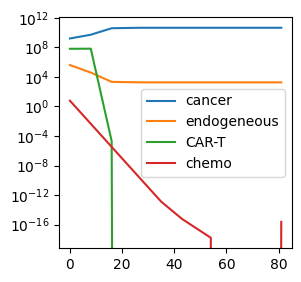

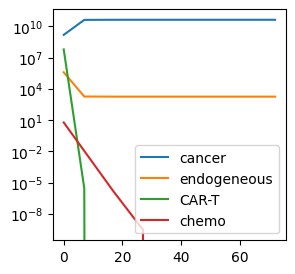

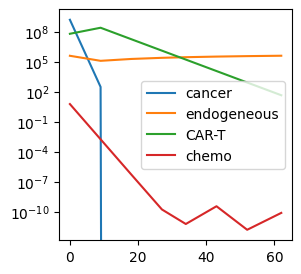

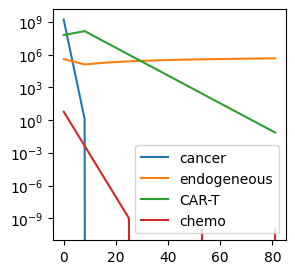

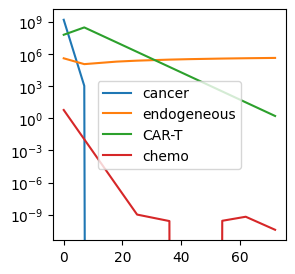

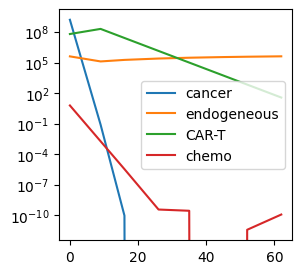

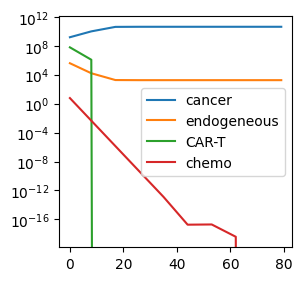

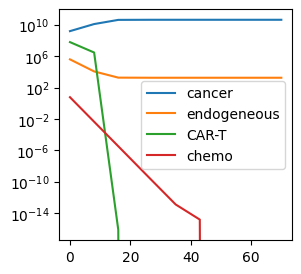

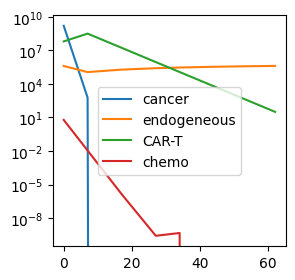

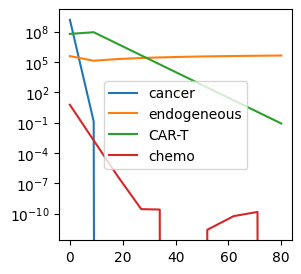

In [7]:
for times, obs in zip(obs_times_all, observations_all):
    plt.figure(figsize=(3, 3))
    plt.semilogy(times, obs[0], label="cancer")
    plt.semilogy(times, obs[1], label="endogeneous")
    plt.semilogy(times, obs[2], label="CAR-T")
    plt.semilogy(times, obs[3], label="chemo")
    plt.legend()
    plt.show()